# Establishing the Uncorrected Baseline in the Dual-Injection Condition

## Overview

After defining and validating the correction algorithm in the previous section, the next step was to examine the same dual-injection condition before algorithmic correction was applied. In this experiment, GCaMP6f and jRGECO1a were co-expressed and recorded under green-only excitation, red-only excitation, and simultaneous dual excitation.

The purpose of this stage was not yet to resolve the mixed signal, but to establish the uncorrected reference condition against which the corrected result could later be evaluated. This section therefore characterizes how the dual-injection recording appears when the correction algorithm is withheld and identifies the residual green-derived contribution that remains embedded in the mixed response.

## Spectral and Time-Series Responses Before Correction

The first step was to examine how the co-expressed dual-injection recording appeared before correction under green-only excitation, red-only excitation, and simultaneous dual excitation. At the spectral level, this comparison was used to determine whether the mixed condition could be interpreted as a simple superposition of the two expected channels or whether residual overlap remained embedded in the recorded response. This comparison established the uncorrected spectral baseline for the dual-injection condition.

At the time-series level, the same comparison was extended to reward-aligned fluorescence traces so that the mixed response could be evaluated not only by spectral profile but also by event-related signal dynamics. This made it possible to determine whether a visible green-derived component remained embedded in the red-associated response before any algorithmic separation was applied.

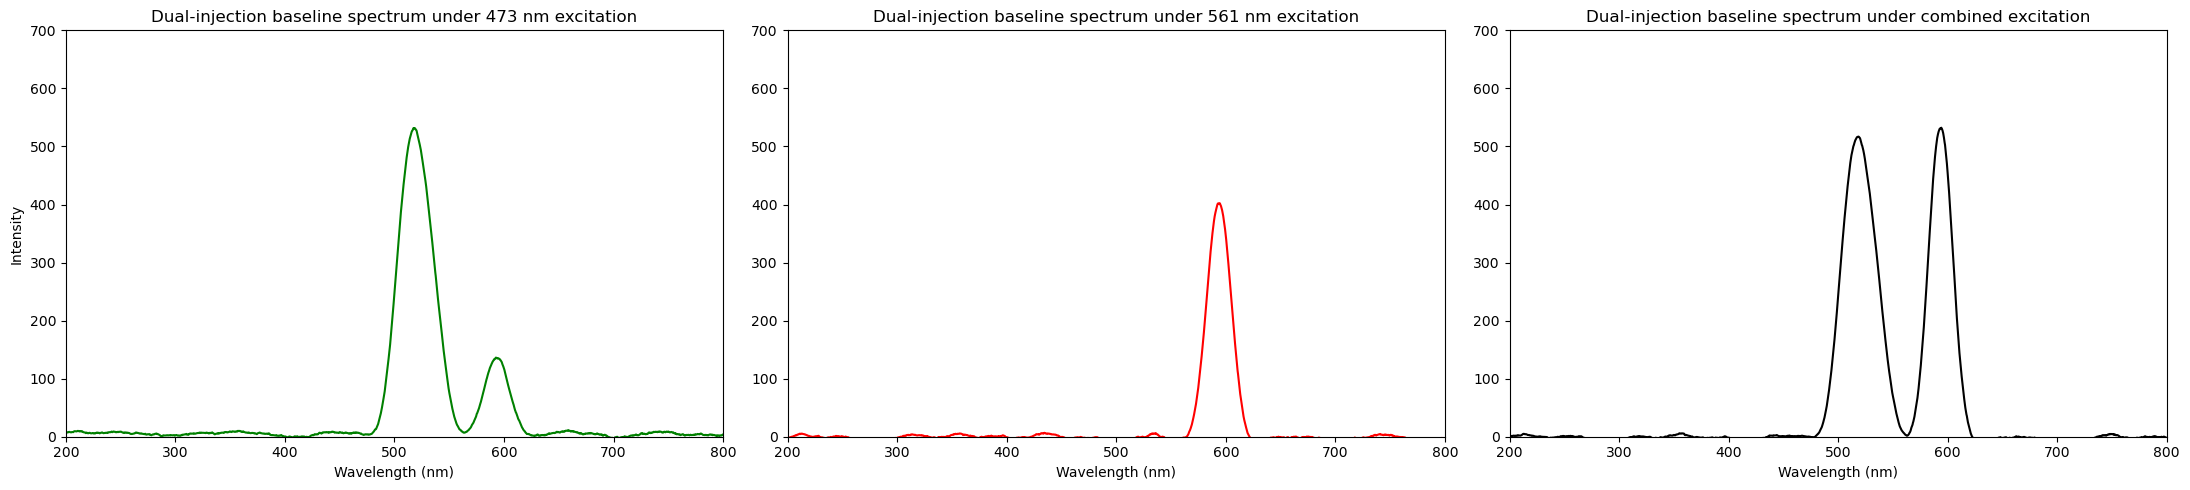

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load representative dual-injection baseline spectra before algorithmic correction
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR.parent / "data" / "baseline" / "GCaMP+jRGECO"

g_file = DATA_DIR / "Flna30_g25uw_noref.txt"
r_file = DATA_DIR / "Flna30_r25uw_noref.txt"
gr_file = DATA_DIR / "Flna30_gr25uw_noref.txt"

g = np.loadtxt(g_file)
r = np.loadtxt(r_file)
gr = np.loadtxt(gr_file)

g_x, g_y = g[:, 0], g[:, 1]
r_x, r_y = r[:, 0], r[:, 1]
gr_x, gr_y = gr[:, 0], gr[:, 1]
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# --- Green: 473nm 25uW ---
axes[0].plot(g_x, g_y, color='green')
axes[0].set_title("Dual-injection baseline spectrum under 473 nm excitation")
axes[0].set_xlim(200, 800)
axes[0].set_ylim(0, 700)
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Intensity")

# --- Red: 561nm 25uW ---
axes[1].plot(r_x, r_y, color='red')
axes[1].set_title("Dual-injection baseline spectrum under 561 nm excitation")
axes[1].set_xlim(200, 800)
axes[1].set_ylim(0, 700)
axes[1].set_xlabel("Wavelength (nm)")

# --- Mixed: 473+561nm 25uW ---
axes[2].plot(gr_x, gr_y, color='black')
axes[2].set_title("Dual-injection baseline spectrum under combined excitation")
axes[2].set_xlim(200, 800)
axes[2].set_ylim(0, 700)
axes[2].set_xlabel("Wavelength (nm)")

plt.tight_layout()
plt.show()


**Figure 1. Uncorrected baseline spectra from the dual-injection condition under separate and combined excitation.**  
Representative spectra were compared under green-only excitation, red-only excitation, and simultaneous dual excitation before application of the correction algorithm. The mixed spectrum was used as the spectral reference condition for evaluating whether the dual-injection recording could be interpreted as a simple combination of the expected channels or whether residual overlap remained embedded in the response.

Uncorrected dual-injection datasets loaded successfully.
Unified Y-axis range → [-49.543, 700.799]


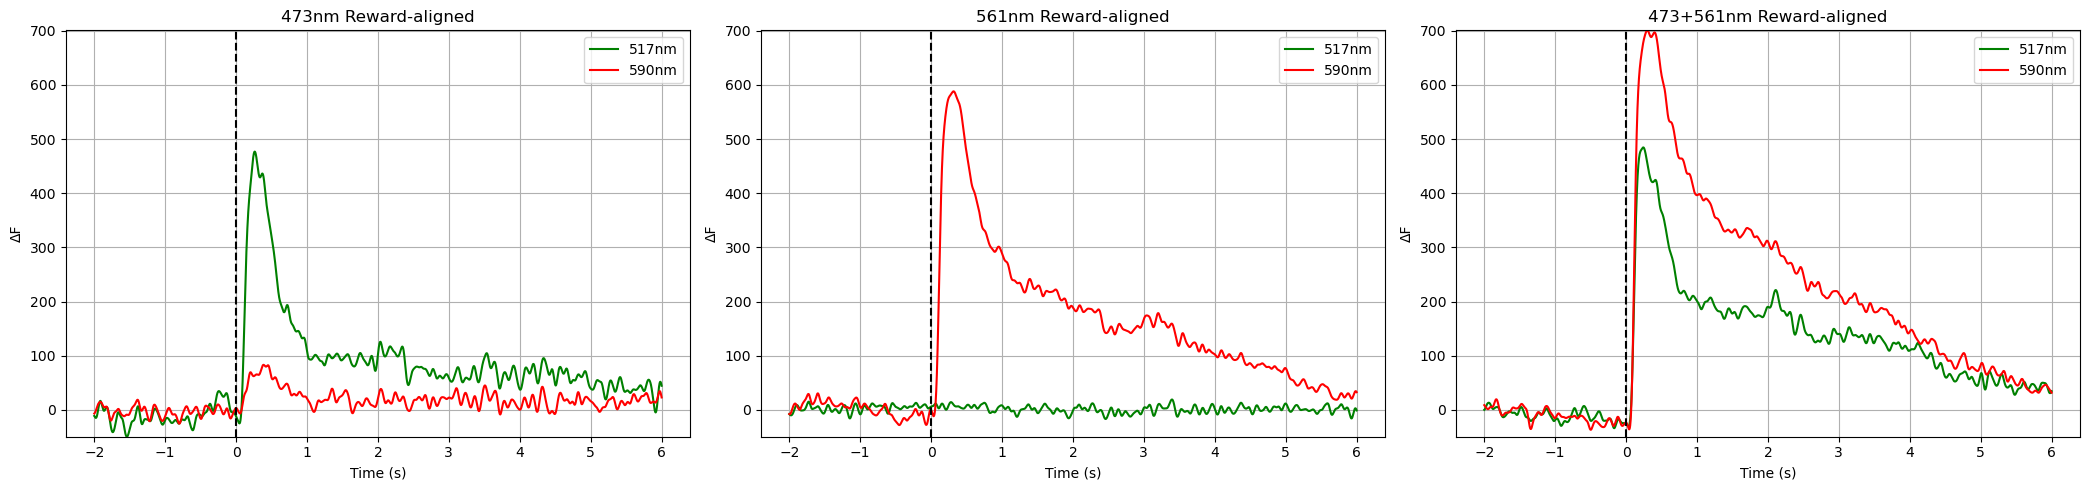

In [3]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

def load_stimuli_file(mat_path):
    """Load a standardized stimuli dataset for dual-injection comparison."""
    data = loadmat(mat_path)

    photo1 = data["photo1"].flatten()
    photo2 = data["photo2"].flatten()
    sol1times = data["sol1times"].flatten()
    downsamplingrate = int(data["downsamplingrate"][0][0])

    return photo1, photo2, sol1times, downsamplingrate

# Load reward-aligned sample datasets for the uncorrected dual-injection comparison
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR.parent / "data" / "stimuli_file" / "GCaMP+jRGECO"

file_473 = DATA_DIR / "Flna30_473nm_stimuli_python.mat"
file_561 = DATA_DIR / "Flna30_561nm_stimuli_python.mat"
file_mixed = DATA_DIR / "Flna30_473+561nm_stimuli_python.mat"

photo1_A, photo2_A, sol1_A, rate_A = load_stimuli_file(file_473)
photo1_B, photo2_B, sol1_B, rate_B = load_stimuli_file(file_561)
photo1_C, photo2_C, sol1_C, rate_C = load_stimuli_file(file_mixed)

print("Uncorrected dual-injection datasets loaded successfully.")


# Compute reward-aligned signal segments in the green and red measurement ranges
# to compare uncorrected responses across excitation conditions
def compute_reward_aligned(photo1, photo2, sol1times, rate):
    pre, post = 2, 6

    photometry1_sol1 = []
    photometry2_sol1 = []

    for t in sol1times:
        idx = int(t * rate)

        start = idx - int(pre * rate)
        end = idx + int(post * rate)

        base_start = idx - int(3 * rate)
        base_end = idx - int(2 * rate)

        if start >= 0 and end < len(photo1) and base_start >= 0 and base_end < len(photo1):

            baseline1 = np.mean(photo1[base_start:base_end])
            baseline2 = np.mean(photo2[base_start:base_end])

            segment1 = photo1[start:end] - baseline1
            segment2 = photo2[start:end] - baseline2

            photometry1_sol1.append(segment1)
            photometry2_sol1.append(segment2)

    photometry1_sol1 = np.array(photometry1_sol1)
    photometry2_sol1 = np.array(photometry2_sol1)

    if len(photometry1_sol1) == 0:
        raise ValueError("No valid reward-aligned segments found.")

    time_axis = np.linspace(-pre, post, photometry1_sol1.shape[1])

    return photometry1_sol1, photometry2_sol1, time_axis

p1_A, p2_A, t_A = compute_reward_aligned(photo1_A, photo2_A, sol1_A, rate_A)
p1_B, p2_B, t_B = compute_reward_aligned(photo1_B, photo2_B, sol1_B, rate_B)
p1_C, p2_C, t_C = compute_reward_aligned(photo1_C, photo2_C, sol1_C, rate_C)

mean_A_1 = p1_A.mean(axis=0)
mean_A_2 = p2_A.mean(axis=0)
mean_B_1 = p1_B.mean(axis=0)
mean_B_2 = p2_B.mean(axis=0)
mean_C_1 = p1_C.mean(axis=0)
mean_C_2 = p2_C.mean(axis=0)

ymin = min(
    np.min(mean_A_1), np.min(mean_A_2),
    np.min(mean_B_1), np.min(mean_B_2),
    np.min(mean_C_1), np.min(mean_C_2)
)

ymax = max(
    np.max(mean_A_1), np.max(mean_A_2),
    np.max(mean_B_1), np.max(mean_B_2),
    np.max(mean_C_1), np.max(mean_C_2)
)

print(f"Unified Y-axis range → [{ymin:.3f}, {ymax:.3f}]")

plt.figure(figsize=(21, 5))

# ---- LEFT: 473nm ----
plt.subplot(1, 3, 1)
plt.plot(t_A, mean_A_1, color='green', label='517nm')
plt.plot(t_A, mean_A_2, color='red', label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('473nm Reward-aligned')
plt.xlabel('Time (s)')
plt.ylabel('ΔF')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

# ---- MIDDLE: 561nm ----
plt.subplot(1, 3, 2)
plt.plot(t_B, mean_B_1, color='green', label='517nm')
plt.plot(t_B, mean_B_2, color='red', label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('561nm Reward-aligned')
plt.xlabel('Time (s)')
plt.ylabel('ΔF')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

# ---- RIGHT: 473+561nm ----
plt.subplot(1, 3, 3)
plt.plot(t_C, mean_C_1, color='green', label='517nm')
plt.plot(t_C, mean_C_2, color='red', label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('473+561nm Reward-aligned')
plt.xlabel('Time (s)')
plt.ylabel('ΔF')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

plt.tight_layout()
plt.show()

**Figure 2. Reward-aligned fluorescence responses from the uncorrected dual-injection condition.**  
Dual-injection recordings were compared under green-only excitation, red-only excitation, and simultaneous dual excitation using reward-aligned fluorescence traces reconstructed from the standardized session datasets. Before correction, the mixed condition retained signal characteristics associated with the green-driven response, indicating that the recorded dual-excitation trace could not yet be interpreted as a cleanly isolated red-associated signal.

## Standardized Comparison of the Mixed Response

Because raw fluorescence amplitude can differ across channels and excitation conditions, the dual-injection responses were also compared after z-score normalization. This step placed the mixed response on a common scale and allowed the relative contribution of each channel to be evaluated more directly.

The standardized comparison was used to determine whether the mixed condition remained biased toward the green-associated signal even before correction, thereby establishing the direct comparison reference for the algorithm-corrected result shown in the following section.

Uncorrected dual-injection datasets loaded successfully.
Valid trials (473nm): 30
Valid trials (561nm): 50
Valid trials (473+561nm): 50
Unified Y-axis range (z-score) → [-0.602, 11.319]


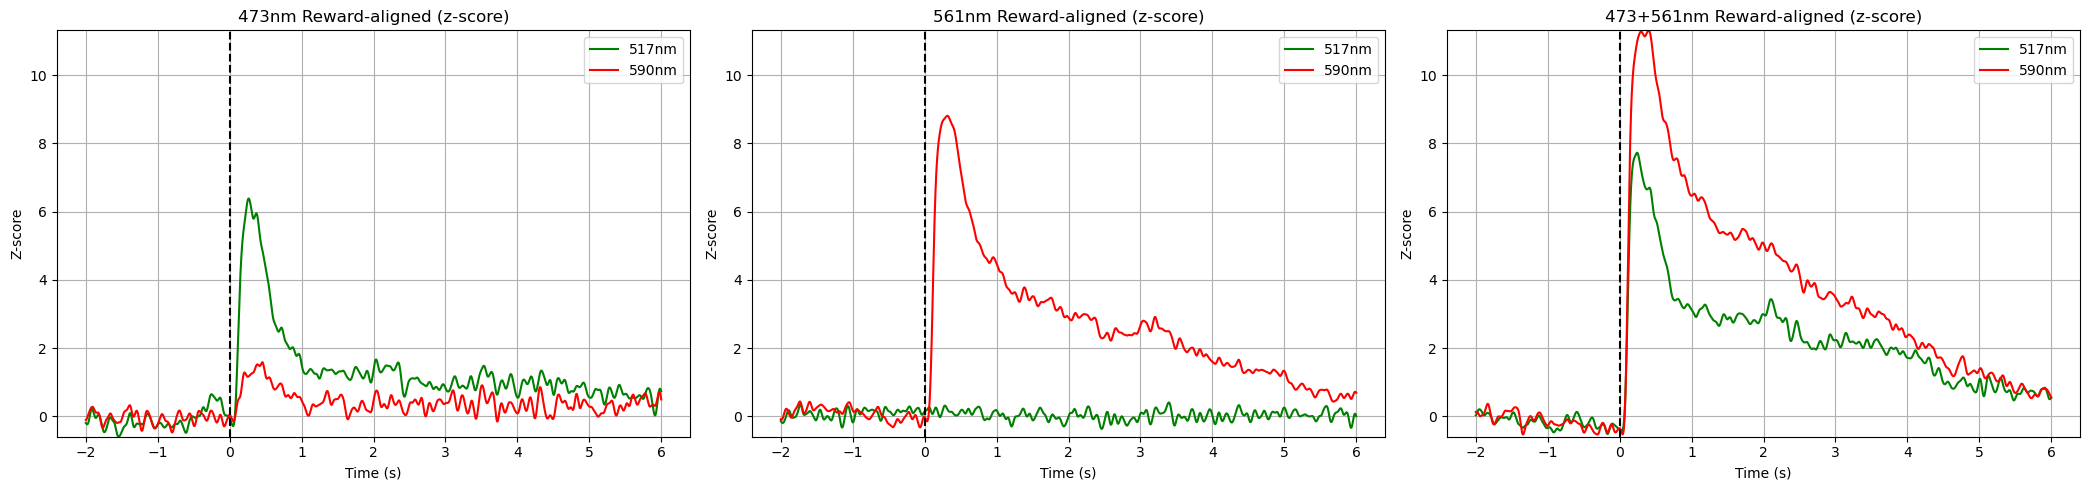

In [4]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

def load_stimuli_file(mat_path):
    """Load a standardized stimuli dataset for dual-injection comparison."""
    data = loadmat(mat_path)

    photo1 = data["photo1"].flatten()
    photo2 = data["photo2"].flatten()
    sol1times = data["sol1times"].flatten()
    downsamplingrate = int(data["downsamplingrate"][0][0])

    return photo1, photo2, sol1times, downsamplingrate

# Load reward-aligned sample datasets for the uncorrected dual-injection comparison
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR.parent / "data" / "stimuli_file" / "GCaMP+jRGECO"

file_473 = DATA_DIR / "Flna30_473nm_stimuli_python.mat"
file_561 = DATA_DIR / "Flna30_561nm_stimuli_python.mat"
file_mixed = DATA_DIR / "Flna30_473+561nm_stimuli_python.mat"

photo1_A, photo2_A, sol1_A, rate_A = load_stimuli_file(file_473)
photo1_B, photo2_B, sol1_B, rate_B = load_stimuli_file(file_561)
photo1_C, photo2_C, sol1_C, rate_C = load_stimuli_file(file_mixed)

print("Uncorrected dual-injection datasets loaded successfully.")

# Compute reward-aligned signal segments in the green and red measurement ranges
# to compare uncorrected responses across excitation conditions
def compute_reward_aligned_zscore(photo1, photo2, sol1times, rate):
    pre, post = 2, 6  # -2 ~ +6 s

    zphoto1_trials = []
    zphoto2_trials = []

    for t in sol1times:
        idx = int(t * rate)

        start = idx - int(pre * rate)
        end   = idx + int(post * rate)

        base_start = idx - int(3 * rate)
        base_end   = idx - int(2 * rate)

        if start >= 0 and end < len(photo1) and base_start >= 0 and base_end < len(photo1):

            base1 = photo1[base_start:base_end]
            base2 = photo2[base_start:base_end]

            mean1 = np.mean(base1)
            std1  = np.std(base1)
            mean2 = np.mean(base2)
            std2  = np.std(base2)

            if std1 < 1e-6 or std2 < 1e-6:
                continue

            seg1 = photo1[start:end]
            seg2 = photo2[start:end]

            zseg1 = (seg1 - mean1) / std1
            zseg2 = (seg2 - mean2) / std2

            zphoto1_trials.append(zseg1)
            zphoto2_trials.append(zseg2)

    zphoto1_trials = np.array(zphoto1_trials)
    zphoto2_trials = np.array(zphoto2_trials)

    if len(zphoto1_trials) == 0:
        raise ValueError("No valid reward-aligned z-score trials found.")

    time_vec = np.linspace(-pre, post, zphoto1_trials.shape[1])

    return zphoto1_trials, zphoto2_trials, time_vec

z1_A, z2_A, t_A = compute_reward_aligned_zscore(photo1_A, photo2_A, sol1_A, rate_A)
z1_B, z2_B, t_B = compute_reward_aligned_zscore(photo1_B, photo2_B, sol1_B, rate_B)
z1_C, z2_C, t_C = compute_reward_aligned_zscore(photo1_C, photo2_C, sol1_C, rate_C)

print(f"Valid trials (473nm): {z1_A.shape[0]}")
print(f"Valid trials (561nm): {z1_B.shape[0]}")
print(f"Valid trials (473+561nm): {z1_C.shape[0]}")

mean_A_1 = z1_A.mean(axis=0)
mean_A_2 = z2_A.mean(axis=0)

mean_B_1 = z1_B.mean(axis=0)
mean_B_2 = z2_B.mean(axis=0)

mean_C_1 = z1_C.mean(axis=0)
mean_C_2 = z2_C.mean(axis=0)

ymin = min(
    np.min(mean_A_1), np.min(mean_A_2),
    np.min(mean_B_1), np.min(mean_B_2),
    np.min(mean_C_1), np.min(mean_C_2)
)

ymax = max(
    np.max(mean_A_1), np.max(mean_A_2),
    np.max(mean_B_1), np.max(mean_B_2),
    np.max(mean_C_1), np.max(mean_C_2)
)

print(f"Unified Y-axis range (z-score) → [{ymin:.3f}, {ymax:.3f}]")

plt.figure(figsize=(21, 5))

# ---- LEFT: 473nm ----
plt.subplot(1, 3, 1)
plt.plot(t_A, mean_A_1, color='green', label='517nm')
plt.plot(t_A, mean_A_2, color='red', label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('473nm Reward-aligned (z-score)')
plt.xlabel('Time (s)')
plt.ylabel('Z-score')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

# ---- MIDDLE: 561nm ----
plt.subplot(1, 3, 2)
plt.plot(t_B, mean_B_1, color='green', label='517nm')
plt.plot(t_B, mean_B_2, color='red', label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('561nm Reward-aligned (z-score)')
plt.xlabel('Time (s)')
plt.ylabel('Z-score')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

# ---- RIGHT: 473+561nm ----
plt.subplot(1, 3, 3)
plt.plot(t_C, mean_C_1, color='green', label='517nm')
plt.plot(t_C, mean_C_2, color='red', label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('473+561nm Reward-aligned (z-score)')
plt.xlabel('Time (s)')
plt.ylabel('Z-score')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

plt.tight_layout()
plt.show()

**Figure 3. Standardized comparison of the uncorrected mixed response in the dual-injection condition.**  
Reward-aligned traces from the dual-injection recordings were transformed to z-scores so that responses across excitation conditions could be compared on a common scale. Even after normalization, the mixed condition retained a visible green-associated component, confirming that the uncorrected response still contained residual contamination before algorithmic separation.

## Residual Green-Derived Component in the Uncorrected Signal

The key observation from the uncorrected dual-injection recording was that the mixed condition still retained a measurable green-derived component. This residual contribution was evident both in the spectral comparison and in the event-aligned response, indicating that the red-associated measurement could not yet be interpreted as an isolated red-sensor signal.

This residual signal defined the practical limitation of the uncorrected recording and established the reference pattern against which the corrected result could later be evaluated.

## Outcome

This stage established the uncorrected baseline for the dual-injection condition. The comparisons showed that, before algorithmic correction, the mixed recording could not be interpreted as a clean separation of green and red sensor activity because a measurable green-derived component remained embedded in the combined response.

This baseline was essential because it defined the exact limitation that the correction algorithm was designed to address. The following section applies the correction algorithm to the same dual-injection condition in order to test whether that residual green-derived contribution can be reduced in practice.